In [4]:
from pathlib import Path
import pandas as pd

## EasyOCR + Corte justo + colorido

In [19]:
resultado_easy = Path(r"EASY_justo.csv")
df = pd.read_csv(resultado_easy)
df.head(30)

,intervalo,texto_bruto,texto_limpo,placa,confianca_ocr,confianca_letras,confianca_placa
0,0-19,HONVDUH,HONVDUH,HONDUH,0.4104,85.71,0.0
1,0-19,HONVDUH,HONVDUH,HONDUH,0.4104,85.71,0.0
2,21-42,TIMELESS,TIMELESS,TIMELESS,0.4441,100.00,100.0
3,21-42,TIMELESS,TIMELESS,TIMELESS,0.4441,100.00,100.0
4,43-60,EEIABUG,EEIABUG,EEWABUG,0.2439,85.71,0.0
5,43-60,EEIABUG,EEIABUG,EEWABUG,0.2439,85.71,0.0
6,61-79,PIKACHU,PIKACHU,PIKACHU,0.9998,100.00,100.0
7,61-79,PIKACHU,PIKACHU,PIKACHU,0.9998,100.00,100.0
8,80-100,OHTTFIU,OHTTFIU,OHIFIT,0.0806,57.14,0.0
9,80-100,OHTTFIU,OHTTFIU,OHIFIT,0.0806,57.14,0.0


In [20]:
df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
df_selecionado

,intervalo,texto_bruto,texto_limpo,placa,confianca_ocr,confianca_letras,confianca_placa
0,0-19,HONVDUH,HONVDUH,HONDUH,0.4104,85.71,0.0
2,21-42,TIMELESS,TIMELESS,TIMELESS,0.4441,100.00,100.0
4,43-60,EEIABUG,EEIABUG,EEWABUG,0.2439,85.71,0.0
6,61-79,PIKACHU,PIKACHU,PIKACHU,0.9998,100.00,100.0
8,80-100,OHTTFIU,OHTTFIU,OHIFIT,0.0806,57.14,0.0
10,101-117,EXGAS,EXGAS,EWGAS,0.3558,80.00,0.0
12,118-145,OFZELDA,OFZELDA,OFZELDA,0.7174,100.00,100.0
14,146-160,BYE401K,BYE401K,BYE4O1K,0.9163,85.71,0.0
16,161-183,KUAHA,KUAHA,MUAHAHA,0.1373,57.14,0.0
18,184-202,ORINNIE,ORINNIE,ORINNIE,0.2832,100.00,100.0


In [17]:
import pandas as pd

# --- leitura ---
df = pd.read_csv("EASY_justo.csv")

# --- limpeza e tipos ---
df["intervalo"] = df["intervalo"].astype(str).str.strip()
for col in ["confianca_ocr","confianca_letras","confianca_placa"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- lista de intervalos esperados em ordem ---
ordem = ["0-19","21-42","43-60","61-79","80-100","101-117","118-145","146-160",
         "161-183","184-202","203-224","225-243","244-258","259-307"]

# --- métricas globais ---
acc_letra_global  = df["confianca_letras"].mean()
acc_placa_global  = df["confianca_placa"].mean()

print(f"Acurácia por letra (global): {acc_letra_global:.3f}")
print(f"Acurácia de placa (global): {acc_placa_global:.3f}")

# --- métricas por intervalo ---
por_intervalo = (df.groupby("intervalo")
                   .agg(acc_letra=("confianca_letras","mean"),
                        acc_placa=("confianca_placa","mean"),
                        n=("confianca_letras","size"))
                   .reindex(ordem)
                   .reset_index())

# --- exibe todos em ordem ---
print("\nMétricas por intervalo:")
print(por_intervalo.to_string(index=False))

# (opcional) filtrar leituras muito inseguras e recalcular
thr = 0.50  # exemplo
filtrado = df[df["confianca_ocr"] >= thr]
print("\nCom filtro de confiança OCR >= 0.50")
print("Acurácia por letra:", filtrado["confianca_letras"].mean())
print("Acurácia de placa:", filtrado["confianca_placa"].mean())

Acurácia por letra (global): 82.881
Acurácia de placa (global): 35.714

Métricas por intervalo:
intervalo  acc_letra  acc_placa  n
     0-19      85.71        0.0  2
    21-42     100.00      100.0  2
    43-60      85.71        0.0  2
    61-79     100.00      100.0  2
   80-100      57.14        0.0  2
  101-117      80.00        0.0  2
  118-145     100.00      100.0  2
  146-160      85.71        0.0  2
  161-183      57.14        0.0  2
  184-202     100.00      100.0  2
  203-224      85.71        0.0  2
  225-243     100.00      100.0  2
  244-258      85.71        0.0  2
  259-307      37.50        0.0  2

Com filtro de confiança OCR >= 0.50
Acurácia por letra: 92.855
Acurácia de placa: 50.0


## Easy corte justo + OTSU

In [ ]:
resultado_easy = Path(r"runs\detect\placas_varios_recortes\Planilhas_recortes\easyOCR\EASY_justo_otsu.csv")
df = pd.read_csv(resultado_easy)
df.head(30)

In [23]:
df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
df_selecionado

,intervalo,texto_bruto,texto_limpo,placa,confianca_ocr,confianca_letras,confianca_placa
0,0-19,HOWDUH,HOWDUH,HONDUH,0.3277,83.33,0.0
2,21-42,TLE55,TLE55,TIMELESS,0.2751,37.50,0.0
4,43-60,EELABUG,EELABUG,EEWABUG,0.3490,85.71,0.0
6,61-79,PIKACHU,PIKACHU,PIKACHU,0.9979,100.00,100.0
8,80-100,FIT,FIT,OHIFIT,0.9992,50.00,0.0
10,101-117,E9WS,E9WS,EWGAS,0.4356,40.00,0.0
12,118-145,MFZELA,MFZELA,OFZELDA,0.8976,71.43,0.0
14,146-160,BYEI401K7,BYEI401K7,BYE4O1K,0.2282,66.67,0.0
16,161-183,MAHAH,MAHAH,MUAHAHA,0.5519,71.43,0.0
18,184-202,IORINNHES,IORINNHES,ORINNIE,0.0713,66.67,0.0


In [21]:
resultado_easy = Path(r"runs\detect\placas_varios_recortes\Planilhas_recortes\easyOCR\EASY_justo_otsu.csv")
df = pd.read_csv(resultado_easy)
df.head(30)

df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
df_selecionado


import pandas as pd

# --- leitura ---
df = pd.read_csv("runs\detect\placas_varios_recortes\Planilhas_recortes\easyOCR\EASY_justo_otsu.csv")

# --- limpeza e tipos ---
df["intervalo"] = df["intervalo"].astype(str).str.strip()
for col in ["confianca_ocr","confianca_letras","confianca_placa"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- lista de intervalos esperados em ordem ---
ordem = ["0-19","21-42","43-60","61-79","80-100","101-117","118-145","146-160",
         "161-183","184-202","203-224","225-243","244-258","259-307"]

# --- métricas globais ---
acc_letra_global  = df["confianca_letras"].mean()
acc_placa_global  = df["confianca_placa"].mean()

print(f"Acurácia por letra (global): {acc_letra_global:.3f}")
print(f"Acurácia de placa (global): {acc_placa_global:.3f}")

# --- métricas por intervalo ---
por_intervalo = (df.groupby("intervalo")
                   .agg(acc_letra=("confianca_letras","mean"),
                        acc_placa=("confianca_placa","mean"),
                        n=("confianca_letras","size"))
                   .reindex(ordem)
                   .reset_index())

# --- exibe todos em ordem ---
print("\nMétricas por intervalo:")
print(por_intervalo.to_string(index=False))

# (opcional) filtrar leituras muito inseguras e recalcular
thr = 0.50  # exemplo
filtrado = df[df["confianca_ocr"] >= thr]
print("\nCom filtro de confiança OCR >= 0.50")
print("Acurácia por letra:", filtrado["confianca_letras"].mean())
print("Acurácia de placa:", filtrado["confianca_placa"].mean())



Acurácia por letra (global): 67.440
Acurácia de placa (global): 14.286

Métricas por intervalo:
intervalo  acc_letra  acc_placa  n
     0-19     83.330        0.0  2
    21-42     37.500        0.0  2
    43-60     85.710        0.0  2
    61-79    100.000      100.0  2
   80-100     50.000        0.0  2
  101-117     40.000        0.0  2
  118-145     71.430        0.0  2
  146-160     66.670        0.0  2
  161-183     71.430        0.0  2
  184-202     66.670        0.0  2
  203-224     64.285        0.0  2
  225-243    100.000      100.0  2
  244-258     85.710        0.0  2
  259-307     21.430        0.0  2

Com filtro de confiança OCR >= 0.50
Acurácia por letra: 77.55071428571429
Acurácia de placa: 28.571428571428573


## Easy justo + dapt

In [24]:
resultado_easy = Path(r"runs\detect\placas_varios_recortes\Planilhas_recortes\easyOCR\EASY_justo_ADAPT.csv")
df = pd.read_csv(resultado_easy)
df.head(30)

df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
df_selecionado

,intervalo,texto_bruto,texto_limpo,placa,confianca_ocr,confianca_letras,confianca_placa
0,0-19,HONDUH,HONDUH,HONDUH,0.9757,100.00,100.0
2,21-42,TI6ELE5S,TI6ELE5S,TIMELESS,0.1589,75.00,0.0
4,43-60,FEEWABUG,FEEWABUG,EEWABUG,0.3268,87.50,0.0
6,61-79,PIKACKU,PIKACKU,PIKACHU,0.6704,85.71,0.0
8,80-100,FIT,FIT,OHIFIT,0.9967,50.00,0.0
10,101-117,GIS,GIS,EWGAS,0.6626,40.00,0.0
12,118-145,QFZELDA,QFZELDA,OFZELDA,0.6059,85.71,0.0
14,146-160,BYE4O1K,BYE4O1K,BYE4O1K,0.6683,100.00,100.0
16,161-183,HUAHAHA,HUAHAHA,MUAHAHA,0.6792,85.71,0.0
18,184-202,ORZNNTEL,ORZNNTEL,ORINNIE,0.2695,62.50,0.0


In [25]:
#resultado_easy = Path(r"runs\detect\placas_varios_recortes\Planilhas_recortes\easyOCR\EASY_justo_ADAPT.csv")
#df = pd.read_csv(resultado_easy)
#df.head(30)

#df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
#df_selecionado


import pandas as pd

# --- leitura ---
df = pd.read_csv("runs\detect\placas_varios_recortes\Planilhas_recortes\easyOCR\EASY_justo_ADAPT.csv")

# --- limpeza e tipos ---
df["intervalo"] = df["intervalo"].astype(str).str.strip()
for col in ["confianca_ocr","confianca_letras","confianca_placa"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- lista de intervalos esperados em ordem ---
ordem = ["0-19","21-42","43-60","61-79","80-100","101-117","118-145","146-160",
         "161-183","184-202","203-224","225-243","244-258","259-307"]

# --- métricas globais ---
acc_letra_global  = df["confianca_letras"].mean()
acc_placa_global  = df["confianca_placa"].mean()

print(f"Acurácia por letra (global): {acc_letra_global:.3f}")
print(f"Acurácia de placa (global): {acc_placa_global:.3f}")

# --- métricas por intervalo ---
por_intervalo = (df.groupby("intervalo")
                   .agg(acc_letra=("confianca_letras","mean"),
                        acc_placa=("confianca_placa","mean"),
                        n=("confianca_letras","size"))
                   .reindex(ordem)
                   .reset_index())

# --- exibe todos em ordem ---
print("\nMétricas por intervalo:")
print(por_intervalo.to_string(index=False))

# (opcional) filtrar leituras muito inseguras e recalcular
thr = 0.50  # exemplo
filtrado = df[df["confianca_ocr"] >= thr]
print("\nCom filtro de confiança OCR >= 0.50")
print("Acurácia por letra:", filtrado["confianca_letras"].mean())
print("Acurácia de placa:", filtrado["confianca_placa"].mean())

Acurácia por letra (global): 75.305
Acurácia de placa (global): 25.000

Métricas por intervalo:
intervalo  acc_letra  acc_placa  n
     0-19     100.00      100.0  2
    21-42      75.00        0.0  2
    43-60      75.00        0.0  2
    61-79      85.71        0.0  2
   80-100      50.00        0.0  2
  101-117      40.00        0.0  2
  118-145      85.71        0.0  2
  146-160      93.75       50.0  2
  161-183      85.71        0.0  2
  184-202      62.50        0.0  2
  203-224      72.32        0.0  2
  225-243     100.00      100.0  2
  244-258     100.00      100.0  2
  259-307      28.57        0.0  2

Com filtro de confiança OCR >= 0.50
Acurácia por letra: 80.63333333333333
Acurácia de placa: 38.888888888888886


## EasyOCR com melhora de foto + Corte justo

In [ ]:
resultado_easy_melhorado = Path(r"EASY_justo_melhora_easy.csv")
df_melhorado = pd.read_csv(resultado_easy_melhorado)
df_melhorado.head(20)

In [28]:
resultado_easy = Path(r"EASY_justo_melhora_easy.csv")
df = pd.read_csv(resultado_easy)
df.head(30)

df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
df_selecionado

,intervalo,texto_bruto,texto_limpo,placa,confianca_ocr,confianca_letras,confianca_placa,confianca_placa_produto
0,0-19,HONVDUH,HONVDUH,HONDUH,0.4104,85.71,0.0,35.18
2,21-42,TIMELESS,TIMELESS,TIMELESS,0.4441,100.00,100.0,44.41
4,43-60,EEMABUG,EEMABUG,EEWABUG,0.3380,85.71,0.0,28.98
6,61-79,PIKACHU,PIKACHU,PIKACHU,0.9998,100.00,100.0,99.98
8,80-100,OHTTFIU,OHTTFIU,OHIFIT,0.0806,57.14,0.0,4.61
10,101-117,EXGA5,EXGA5,EWGAS,0.4076,60.00,0.0,24.45
12,118-145,OFZELDA,OFZELDA,OFZELDA,0.7174,100.00,100.0,71.74
14,146-160,BYE401K,BYE401K,BYE4O1K,0.9163,85.71,0.0,78.54
16,161-183,KUAHA,KUAHA,MUAHAHA,0.1373,57.14,0.0,7.85
18,184-202,ORINNIE,ORINNIE,ORINNIE,0.2832,100.00,100.0,28.32


In [27]:
#resultado_easy = Path(r"runs\detect\placas_varios_recortes\Planilhas_recortes\easyOCR\EASY_justo_ADAPT.csv")
#df = pd.read_csv(resultado_easy)
#df.head(30)

#df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
#df_selecionado


import pandas as pd

# --- leitura ---
df = pd.read_csv("EASY_justo_melhora_easy.csv")

# --- limpeza e tipos ---
df["intervalo"] = df["intervalo"].astype(str).str.strip()
for col in ["confianca_ocr","confianca_letras","confianca_placa"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- lista de intervalos esperados em ordem ---
ordem = ["0-19","21-42","43-60","61-79","80-100","101-117","118-145","146-160",
         "161-183","184-202","203-224","225-243","244-258","259-307"]

# --- métricas globais ---
acc_letra_global  = df["confianca_letras"].mean()
acc_placa_global  = df["confianca_placa"].mean()

print(f"Acurácia por letra (global): {acc_letra_global:.3f}")
print(f"Acurácia de placa (global): {acc_placa_global:.3f}")

# --- métricas por intervalo ---
por_intervalo = (df.groupby("intervalo")
                   .agg(acc_letra=("confianca_letras","mean"),
                        acc_placa=("confianca_placa","mean"),
                        n=("confianca_letras","size"))
                   .reindex(ordem)
                   .reset_index())

# --- exibe todos em ordem ---
print("\nMétricas por intervalo:")
print(por_intervalo.to_string(index=False))

# (opcional) filtrar leituras muito inseguras e recalcular
thr = 0.50  # exemplo
filtrado = df[df["confianca_ocr"] >= thr]
print("\nCom filtro de confiança OCR >= 0.50")
print("Acurácia por letra:", filtrado["confianca_letras"].mean())
print("Acurácia de placa:", filtrado["confianca_placa"].mean())

Acurácia por letra (global): 75.305
Acurácia de placa (global): 25.000

Métricas por intervalo:
intervalo  acc_letra  acc_placa  n
     0-19     100.00      100.0  2
    21-42      75.00        0.0  2
    43-60      75.00        0.0  2
    61-79      85.71        0.0  2
   80-100      50.00        0.0  2
  101-117      40.00        0.0  2
  118-145      85.71        0.0  2
  146-160      93.75       50.0  2
  161-183      85.71        0.0  2
  184-202      62.50        0.0  2
  203-224      72.32        0.0  2
  225-243     100.00      100.0  2
  244-258     100.00      100.0  2
  259-307      28.57        0.0  2

Com filtro de confiança OCR >= 0.50
Acurácia por letra: 80.63333333333333
Acurácia de placa: 38.888888888888886


In [13]:
df_melhorado = pd.read_csv("EASY_justo_melhora_easy.csv")

# assegure tipos numéricos
for col in ["confianca_ocr","confianca_letras","confianca_placa","confianca_placa_produto"]:
    df_melhorado[col] = pd.to_numeric(df_melhorado[col], errors="coerce")

# --- métricas globais ---
acc_letra_global  = df_melhorado["confianca_letras"].mean()
acc_placa_global  = df_melhorado["confianca_placa"].mean()
acc_hibrida_global = df_melhorado["confianca_placa_produto"].mean()

print(f"Acurácia por letra (global): {acc_letra_global:.3f}")
print(f"Acurácia de placa (global): {acc_placa_global:.3f}")
print(f"Métrica híbrida (global): {acc_hibrida_global:.3f}")

# --- métricas por intervalo ---
por_intervalo = df_melhorado.groupby("intervalo").agg(
    acc_letra=("confianca_letras","mean"),
    acc_placa=("confianca_placa","mean"),
    acc_hibrida=("confianca_placa_produto","mean"),
    n=("confianca_letras","size")
).reset_index()

print(por_intervalo.head(10))

# (opcional) filtrar leituras muito inseguras e recalcular
thr = 0.50  # exemplo
filtrado = df_melhorado[df_melhorado["confianca_ocr"] >= thr]
print("\nCom filtro de confiança OCR >= 0.50")
print("Acurácia por letra:", filtrado["confianca_letras"].mean())
print("Acurácia de placa:", filtrado["confianca_placa"].mean())

Acurácia por letra (global): 81.006
Acurácia de placa (global): 35.714
Métrica híbrida (global): 49.775
  intervalo  acc_letra  acc_placa  acc_hibrida  n
0      0-19      85.71        0.0        35.18  2
1   101-117      60.00        0.0        24.45  2
2   118-145     100.00      100.0        71.74  2
3   146-160      85.71        0.0        78.54  2
4   161-183      57.14        0.0         7.85  2
5   184-202     100.00      100.0        28.32  2
6   203-224      85.71        0.0        83.68  2
7     21-42     100.00      100.0        44.41  2
8   225-243     100.00      100.0        99.53  2
9   244-258      85.71        0.0        85.35  2

Com filtro de confiança OCR >= 0.50
Acurácia por letra: 92.855
Acurácia de placa: 50.0


## Easy +8px colorido

In [29]:
resultado_easy = Path(r"runs\detect\placas_varios_recortes\Planilhas_recortes\easyOCR\EASY_oito.csv")
df = pd.read_csv(resultado_easy)
df.head(30)

df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
df_selecionado

,intervalo,texto_bruto,texto_limpo,placa,confianca_ocr,confianca_letras,confianca_placa
0,0-19,HONVDUH,HONVDUH,HONDUH,0.4104,85.71,0.0
2,21-42,TIELESS,TIELESS,TIMELESS,0.6150,87.50,0.0
4,43-60,EENABUG,EENABUG,EEWABUG,0.4062,85.71,0.0
6,61-79,PIKACHU,PIKACHU,PIKACHU,1.0000,100.00,100.0
8,80-100,OHTFW,OHTFW,OHIFIT,0.2617,50.00,0.0
10,101-117,EXGA5,EXGA5,EWGAS,0.4076,60.00,0.0
12,118-145,OFZELDA,OFZELDA,OFZELDA,0.7143,100.00,100.0
14,146-160,BYE401K,BYE401K,BYE4O1K,0.9266,85.71,0.0
16,161-183,KUAHA,KUAHA,MUAHAHA,0.1569,57.14,0.0
18,184-202,ORINNIE,ORINNIE,ORINNIE,0.2963,100.00,100.0


In [30]:
#resultado_easy = Path(r"runs\detect\placas_varios_recortes\Planilhas_recortes\easyOCR\EASY_oito.csv")
#df = pd.read_csv(resultado_easy)
#df.head(30)

#df_selecionado = df.loc[[0, 2, 4, 6,8,10,12,14,16,18,20,22,24,26]]
#df_selecionado


import pandas as pd

# --- leitura ---
df = pd.read_csv("runs\detect\placas_varios_recortes\Planilhas_recortes\easyOCR\EASY_oito.csv")

# --- limpeza e tipos ---
df["intervalo"] = df["intervalo"].astype(str).str.strip()
for col in ["confianca_ocr","confianca_letras","confianca_placa"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- lista de intervalos esperados em ordem ---
ordem = ["0-19","21-42","43-60","61-79","80-100","101-117","118-145","146-160",
         "161-183","184-202","203-224","225-243","244-258","259-307"]

# --- métricas globais ---
acc_letra_global  = df["confianca_letras"].mean()
acc_placa_global  = df["confianca_placa"].mean()

print(f"Acurácia por letra (global): {acc_letra_global:.3f}")
print(f"Acurácia de placa (global): {acc_placa_global:.3f}")

# --- métricas por intervalo ---
por_intervalo = (df.groupby("intervalo")
                   .agg(acc_letra=("confianca_letras","mean"),
                        acc_placa=("confianca_placa","mean"),
                        n=("confianca_letras","size"))
                   .reindex(ordem)
                   .reset_index())

# --- exibe todos em ordem ---
print("\nMétricas por intervalo:")
print(por_intervalo.to_string(index=False))

# (opcional) filtrar leituras muito inseguras e recalcular
thr = 0.50  # exemplo
filtrado = df[df["confianca_ocr"] >= thr]
print("\nCom filtro de confiança OCR >= 0.50")
print("Acurácia por letra:", filtrado["confianca_letras"].mean())
print("Acurácia de placa:", filtrado["confianca_placa"].mean())

Acurácia por letra (global): 80.381
Acurácia de placa (global): 32.143

Métricas por intervalo:
intervalo  acc_letra  acc_placa  n
     0-19     85.710        0.0  2
    21-42     87.500        0.0  2
    43-60     85.710        0.0  2
    61-79    100.000      100.0  2
   80-100     50.000        0.0  2
  101-117     70.000        0.0  2
  118-145    100.000      100.0  2
  146-160     85.710        0.0  2
  161-183     57.140        0.0  2
  184-202    100.000      100.0  2
  203-224     92.855       50.0  2
  225-243    100.000      100.0  2
  244-258     85.710        0.0  2
  259-307     25.000        0.0  2

Com filtro de confiança OCR >= 0.50
Acurácia por letra: 92.58076923076925
Acurácia de placa: 46.15384615384615


## Gráfico

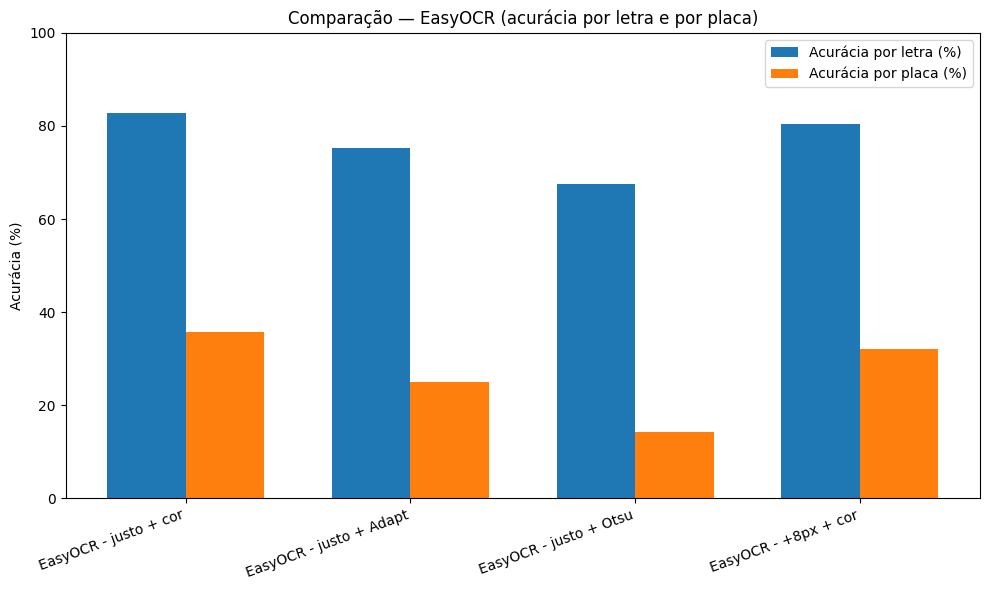

✅ Gráfico salvo como: acuracia_easyocr_barras.png


In [32]:
# salvar como plot_easyocr_barras.py
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------- dados ---------
rows = [
    {"nome": "EasyOCR - justo + cor", "acc_letra": 82.88, "acc_placa": 35.71},
    {"nome": "EasyOCR - justo + Adapt", "acc_letra": 75.30, "acc_placa": 25.00},
    {"nome": "EasyOCR - justo + Otsu", "acc_letra": 67.44, "acc_placa": 14.28},
    {"nome": "EasyOCR - +8px + cor", "acc_letra": 80.38, "acc_placa": 32.14}, 
]
df = pd.DataFrame(rows)

# --------- configuração do gráfico ---------
x = np.arange(len(df))  # posições no eixo x
largura = 0.35          # largura das barras

fig, ax = plt.subplots(figsize=(10, 6))
barras_letra = ax.bar(x - largura/2, df["acc_letra"], largura, label="Acurácia por letra (%)", color="#1f77b4")
barras_placa = ax.bar(x + largura/2, df["acc_placa"], largura, label="Acurácia por placa (%)", color="#ff7f0e")

# --------- ajustes visuais ---------
ax.set_ylabel("Acurácia (%)")
ax.set_title("Comparação — EasyOCR (acurácia por letra e por placa)")
ax.set_xticks(x)
ax.set_xticklabels(df["nome"], rotation=20, ha="right")
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.savefig("acuracia_easyocr_barras.png", dpi=200)
plt.show()

print("✅ Gráfico salvo como: acuracia_easyocr_barras.png")
